<a href="https://colab.research.google.com/github/dgsob/SF2526-VT25/blob/main/DS_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [245]:
using Pkg
Pkg.add(["Distances", "Graphs", "GraphPlot", "LinearAlgebra", "Plots", "MAT", "Images", "NearestNeighbors", "Clustering", "StatsBase", "Cairo", "Fontconfig", "Arpack"])

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [246]:
using Distances, Graphs, GraphPlot, LinearAlgebra, Plots, MAT, Images, NearestNeighbors, Clustering, StatsBase, Arpack
gr()

Plots.GRBackend()

In [247]:
using Random, Cairo

## Exercise 1

### Part (a)

#### 1. Initial State
We begin with our data matrix $X$ and initial centroids $R$:

$$
X = \begin{bmatrix} 1 & 1 & 1 \\ 1.5 & 2 & 0 \\ -0.5 & 0 & -3 \\ 0 & -0.5 & -1 \end{bmatrix}, \quad R = \begin{bmatrix} 3 & 3 & 3 \\ -1 & -1 & 0 \end{bmatrix}
$$


---

#### 2. First Iteration
**Distance Matrix $D$:** (Rows represent points $X_1 \dots X_4$, columns represent distance to $R_1, R_2$)
$$
D = \begin{bmatrix} 3.46 & 3.0 \\ 3.5 & 3.91 \\ 7.57 & 3.2 \\ 6.1 & 1.5 \end{bmatrix}
$$

**Cluster Assignments:**
* $X_1 \rightarrow R_2$
* $X_2 \rightarrow R_1$
* $X_3 \rightarrow R_2$
* $X_4 \rightarrow R_2$

**New Centroids:**
* **$R_1$**: $[1.5, 2, 0]$
* **$R_2$**: $[\frac{1-0.5+0}{3}, \frac{1+0-0.5}{3}, \frac{1-3-1}{3}] \approx [0.167, 0.167, -1]$

---

#### 3. Second Iteration
**Updated Distance Matrix $D$:**
$$
D = \begin{bmatrix} 1.5 & 2.32 \\ 0 & 2.48 \\ 4.12 & 2.11 \\ 3.08 & 0.687 \end{bmatrix}
$$

**Cluster Assignments:**
* $X_1 \rightarrow R_1$
* $X_2 \rightarrow R_1$
* $X_3 \rightarrow R_2$
* $X_4 \rightarrow R_2$

**New Centroids:**
* **$R_1$**: $[\frac{1+1.5}{2}, \frac{1+2}{2}, \frac{1+0}{2}] = [1.25, 1.5, 0.5]$
* **$R_2$**: $[\frac{-0.5+0}{2}, \frac{0-0.5}{2}, \frac{-3-1}{2}] = [-0.25, -0.25, -2]$

---

#### 4. Third Iteration
**Final Distance Matrix $D$:**
$$
D = \begin{bmatrix}
0.75 & 3.482 \\
0.75 & 3.482 \\
4.191 & 1.061 \\
2.795 & 1.061
\end{bmatrix}
$$

**Assignments remain unchanged:**
* $X_1, X_2 \rightarrow R_1$
* $X_3, X_4 \rightarrow R_2$

**Final Centroids:**
> **$R_1 = [1.25, 1.5, 0.5]$**
>
> **$R_2 = [-0.25, -0.25, -2.0]$**

### Part (b)

#### 1. Initial State
We begin with the same data matrix $X$ but a different set of initial centroids $R$:

$$
X = \begin{bmatrix} 1 & 1 & 1 \\ 1.5 & 2 & 0 \\ -0.5 & 0 & -3 \\ 0 & -0.5 & -1 \end{bmatrix}, \quad R = \begin{bmatrix} -0.5 & 0 & -3 \\ -1 & -1 & 1 \end{bmatrix}
$$

---

#### 2. First Iteration
**Distance Matrix $D$:**
$$
D = \begin{bmatrix} 4.39 & 2.83 \\ 4.12 & 4.03 \\ 0 & 4.15 \\ 2.12 & 2.29 \end{bmatrix}
$$

**Cluster Assignments:**
* $X_1 \rightarrow R_2$
* $X_2 \rightarrow R_2$
* $X_3 \rightarrow R_1$
* $X_4 \rightarrow R_1$

**New Centroids:**
* **$R_1$**: $[\frac{-0.5+0}{2}, \frac{0-0.5}{2}, \frac{-3-1}{2}] = [-0.25, -0.25, -2]$
* **$R_2$**: $[\frac{1+1.5}{2}, \frac{1+2}{2}, \frac{1+0}{2}] = [1.25, 1.5, 0.5]$

---

#### 3. Second Iteration
**Updated Distance Matrix $D$:**
$$
D = \begin{bmatrix}
3.482 & 0.75 \\
3.482 & 0.75 \\
1.061 & 4.191 \\
1.061 & 2.795
\end{bmatrix}
$$

**Cluster Assignments:**
* $X_1 \rightarrow R_2$
* $X_2 \rightarrow R_2$
* $X_3 \rightarrow R_1$
* $X_4 \rightarrow R_1$

The assignments are identical to the previous step, meaning the centroids have stabilized.

**Final Centroids:**
> **$R_1 = [-0.25, -0.25, -2.0]$**
>
> **$R_2 = [1.25, 1.5, 0.5]$**

### Computer Code to check the distances

In [248]:
X = [1.0 1.0 1.0;
     1.5 2.0 0.0;
    -0.5 0.0 -3.0;
     0.0 -0.5 -1.0]

# (a)
R_a = [1.25 1.5 0.5; -0.25 -0.25 -2.0]
dist_a = pairwise(Euclidean(), X', R_a')   # 4×2 distance matrix
println("Final distances to centroids (a):"); display(round.(dist_a, digits=3))
assign_a = [argmin(dist_a[i,:]) for i in 1:4] # indicator vectors
println("Assignments (a): ", assign_a)

# (b)
R_b = [-0.25 -0.25 -2.0; 1.25 1.5 0.5]
dist_b = pairwise(Euclidean(), X', R_b')
println("\nFinal distances to centroids (b):"); display(round.(dist_b, digits=3))
assign_b = [argmin(dist_b[i,:]) for i in 1:4]
println("Assignments (b): ", assign_b)

Final distances to centroids (a):


4×2 Matrix{Float64}:
 0.75   3.482
 0.75   3.482
 4.191  1.061
 2.795  1.061

Assignments (a): [1, 1, 2, 2]

Final distances to centroids (b):


4×2 Matrix{Float64}:
 3.482  0.75
 3.482  0.75
 1.061  4.191
 1.061  2.795

Assignments (b): [2, 2, 1, 1]


### Interpretation

There are no differences in the resulting clustering between (a) and (b) - starting with both R-vectors results in assignment of the data points to the same separation, making the solutions equivalent.

This doesn't always have to be the case, as cluster convergence depends on the location of initial centroids, but it is the case for the two checked initial assignments.

The only difference between the two is that (a) took two iterations to converge, while (b) took one - so from this example we can notice that initialization affects the convergence speed, and on this basis starting with centroid assignment as in (b) can be considered better.

## Exercise 2

### Part (a)

In [249]:
# Data
n0, p, c = 5, 3, 2
Random.seed!(0)
A1 = randn(n0, p) .+ c * [1,0,0]'
A2 = randn(n0, p) .+ c * [0,1,0]'
A3 = randn(n0, p) .+ c * [0,0,1]'
A4 = zeros(1, p)
A = vcat(A1, A2, A3, A4)
n = size(A, 1)

# Distance matrix
D = pairwise(Euclidean(), A, dims=1);

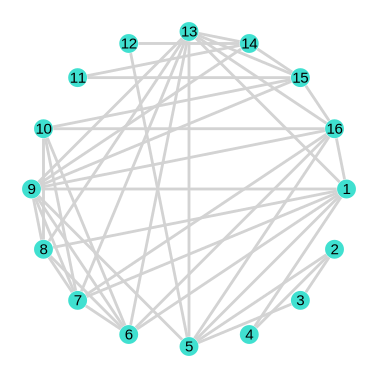

Connected components: 1


In [250]:
# Graph
ϵ = 2.5
G = SimpleGraph(n)
for i in 1:n, j in i+1:n
    if D[i,j] ≤ ϵ
        add_edge!(G, i, j)
    end
end

import Cairo, Fontconfig
p1 = gplot(G, layout=circular_layout, nodelabel=1:n)
display(p1)

# Number of connected components
comps = connected_components(G)
println("Connected components: ", length(comps))

The graph has one connected component.

### Part (b)

To construct the unnormalized Laplacian matrix $L$ and compute its eigenvalues we:
1. Construct the adjacency matrix $W$ of the graph.
2. Compute the degree matrix $D$.
3. Compute the unnormalized Laplacian: $L$ $=$ $D$ $-$ $W$.
4. Compute the eigenvalues and eigenvectors of $L$.
5. Find how many eigenvalues $\approx$ 0 and verify check the multiplicity, as according to $\textit{Lemma 2.3.3}$ in EJ2, multiplicity of $\lambda = 0$ corresponds to the number of connected components (based on part (a), we expect the multiplicity = 1).

In [251]:
W = adjacency_matrix(G)
Deg = Diagonal(vec(sum(W, dims=2)))
L = Deg - W
evals_eigs, _ = eigs(L, nev=5, which=:SM) # nev=5 to get a few smallest eigenvalues
evals = real(evals_eigs) # take the real part, as eigenvalues of symmetric matrices are real
println("Multiplicity of λ=0: ", count(x -> abs(x) < 1e-10, evals)) # Lemma 2.3.3: multiplicity = number of connected components

Multiplicity of λ=0: 1


### Part (c)

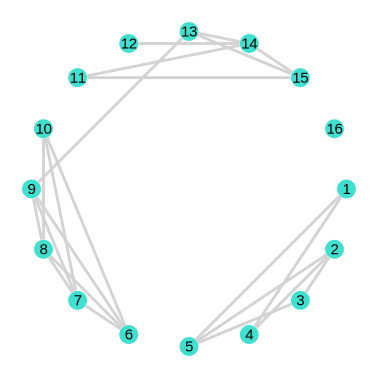

Connected components: 3
Multiplicity of λ=0: 3


In [252]:
n0, p, c = 5, 3, 3
ϵ = 2.5
Random.seed!(0)
A1 = randn(n0, p) .+ c * [1,0,0]'
A2 = randn(n0, p) .+ c * [0,1,0]'
A3 = randn(n0, p) .+ c * [0,0,1]'
A4 = zeros(1, p)
A = vcat(A1, A2, A3, A4)
n = size(A, 1)

D = pairwise(Euclidean(), A, dims=1)
G = SimpleGraph(n)
for i in 1:n, j in i+1:n
    if D[i,j] ≤ ϵ
        add_edge!(G, i, j)
    end
end
p1 = gplot(G, layout=circular_layout, nodelabel=1:n)
display(p1)

# Number of connected components
comps = connected_components(G)
println("Connected components: ", length(comps))

W = adjacency_matrix(G)  # 0/1 weights
Deg = Diagonal(vec(sum(W, dims=2)))
L = Deg - W
evals_eigs, _ = eigs(L, nev=5, which=:SM) # nev=5 to get a few smallest eigenvalues
evals = real(evals_eigs) # take the real part as eigenvalues of symmetric matrices are real
println("Multiplicity of λ=0: ", count(x -> abs(x) < 1e-10, evals))

### Part (d)

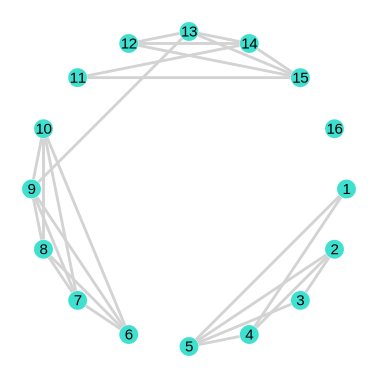

Connected components: 3
Multiplicity of λ=0: 3


In [253]:
n0, p, c = 5, 3, 3.1
ϵ = 2.8
Random.seed!(0)
A1 = randn(n0, p) .+ c * [1,0,0]'
A2 = randn(n0, p) .+ c * [0,1,0]'
A3 = randn(n0, p) .+ c * [0,0,1]'
A4 = zeros(1, p)
A = vcat(A1, A2, A3, A4)
n = size(A, 1)

D = pairwise(Euclidean(), A, dims=1)
G = SimpleGraph(n)
for i in 1:n, j in i+1:n
    if D[i,j] ≤ ϵ
        add_edge!(G, i, j)
    end
end
p1 = gplot(G, layout=circular_layout, nodelabel=1:n)
display(p1)

# Number of connected components
comps = connected_components(G)
println("Connected components: ", length(comps))

W = adjacency_matrix(G)  # 0/1 weights
Deg = Diagonal(vec(sum(W, dims=2)))
L = Deg - W
evals_eigs, _ = eigs(L, nev=5, which=:SM) # nev=5 to get a few smallest eigenvalues
evals = real(evals_eigs) # take the real part as eigenvalues of symmetric matrices are real
println("Multiplicity of λ=0: ", count(x -> abs(x) < 1e-10, evals))

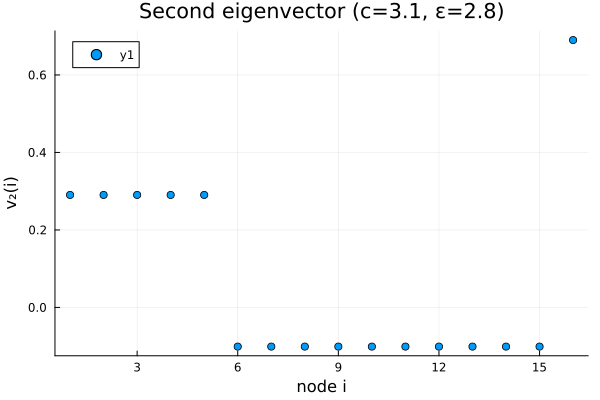

"/content/ex2_v2.png"

In [254]:
F_vals, F_vecs = eigs(L, nev=2, which=:SM)
idx = sortperm(real(F_vals)) # sort based on real parts of eigenvalues
v2 = F_vecs[:, idx[2]] # second smallest eigenvalue's eigenvector

p2 = scatter(1:n, v2, xlabel="node i", ylabel="v₂(i)", title="Second eigenvector (c=3.1, ε=2.8)", markersize=4)
display(p2)
savefig("ex2_v2.png")

From the graph above, we can read the clustring as follows:

The second eigenvector value is the same for the nodes which belong to the same cluster. We can thus deduce, that nodes 1-5 compose one cluster, nodes 6-15 another, and the lonely point 16 composes a third cluster, which aligns with visual assesment one can perform over the graph itself.

## Exercise 3

### Part (a)

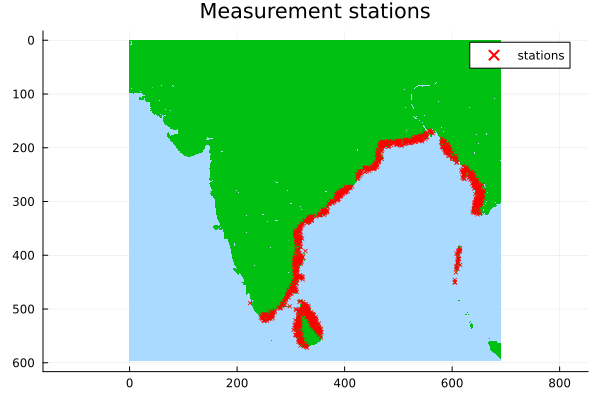

In [255]:
data = matread("bengali_cleanup.mat")
x_coords = data["x_coords"]
y_coords = data["y_coords"]
timeseries = data["timeseries"]
tv = data["tv"] # tv = time vector

map_img = load("bengali_map.png")

function plot_stations(jv)
    p = plot(map_img, aspect_ratio=:equal, title="Measurement stations")
    scatter!(p, y_coords[jv], x_coords[jv], color=:red, markershape=:x, markersize=2, label="stations")
    display(p)
end

plot_stations(1:937)

### Part (b)

In [256]:
Dist = pairwise(Euclidean(), timeseries, dims=1)

println("Distance 102 to 280: ", round(Dist[102,280], digits=2))
println("Distance 102 to 10 : ", round(Dist[102,10],  digits=2))
println("Distance 280 to 10 : ", round(Dist[280,10], digits=2))

Distance 102 to 280: 3.35
Distance 102 to 10 : 4.61
Distance 280 to 10 : 4.84


Distances make sense: Burma's station 10 pollution is further away, as far as its characteristic goes, from the pollution from both Kolkata stations.

### Part (c)

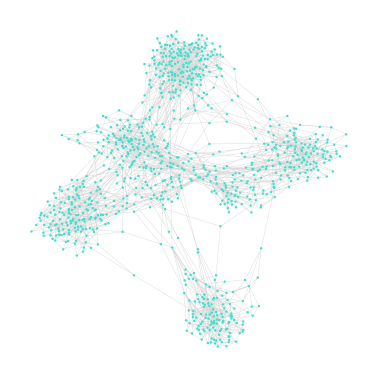

In [257]:
k = 3
tree = BallTree(timeseries')
W_knn = zeros(size(timeseries,1), size(timeseries,1))

for i in 1:size(timeseries,1)
    idx, _ = knn(tree, timeseries[i,:], k+1, true)
    for j in idx[2:end] # skip self
        W_knn[i,j] = 1.0
        W_knn[j,i] = 1.0
    end
end

G_knn = SimpleGraph(W_knn)
p_knn = gplot(G_knn, layout=spring_layout)
display(p_knn)

As a human I confirm being able to identify 7 clusters, although separation of the ones crumped in between the center - up to the top right, can be dificult.

### Part (d)

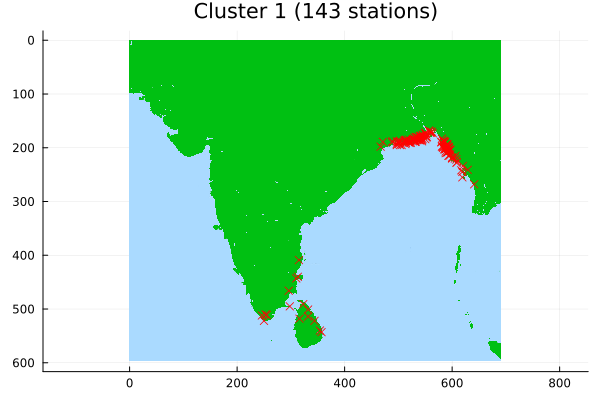

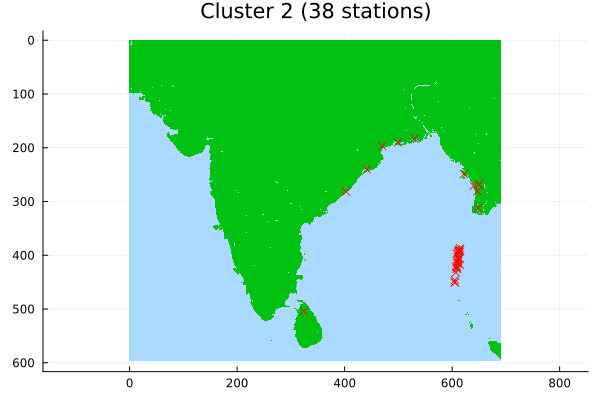

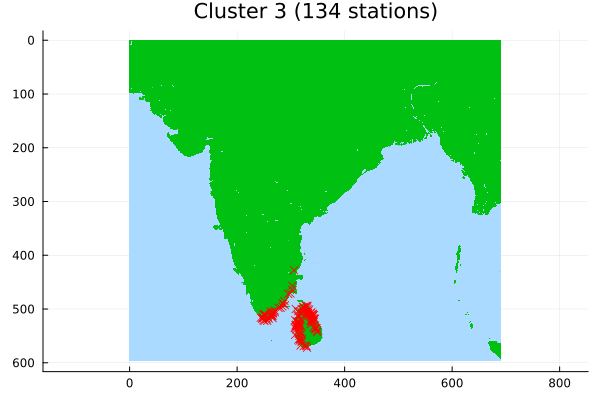

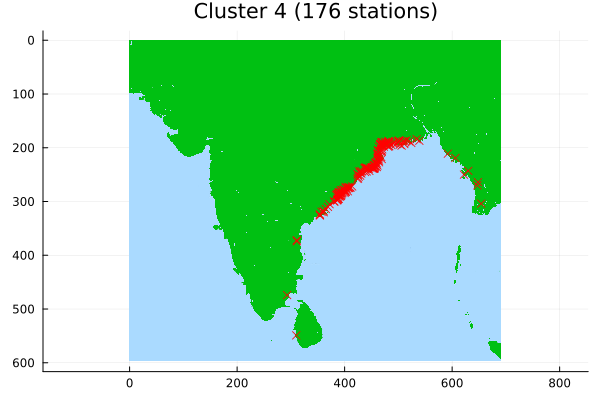

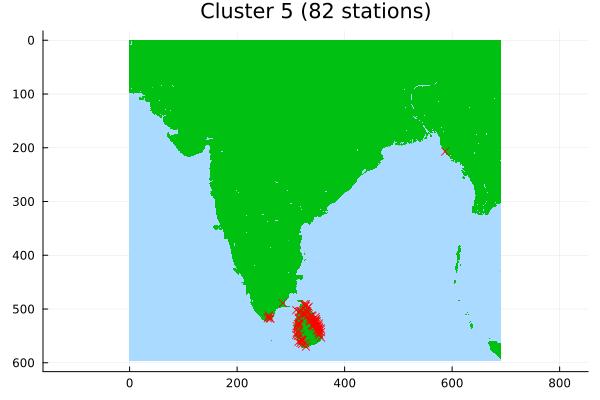

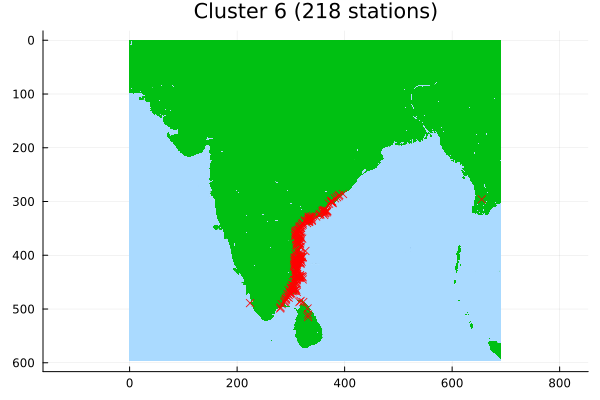

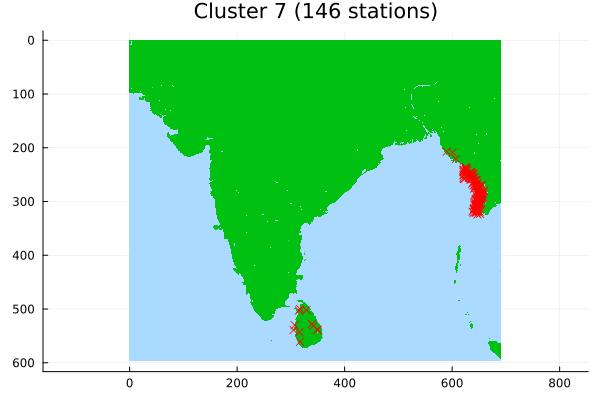

In [258]:
# Spectral clustering (RatioCut, 7 clusters)
function spectral_clustering(W, k_clusters)
    Deg = Diagonal(vec(sum(W, dims=2)))
    L = Deg - W
    F = eigen(L)
    idx = sortperm(F.values)
    U = F.vectors[:, idx[2:k_clusters+1]]   # Fiedler + next
    res = kmeans(U', k_clusters; maxiter=1000)
    return res.assignments
end

labels7 = spectral_clustering(W_knn, 7)

# Plot each cluster on map
for cl in 1:7
    idx = findall(labels7 .== cl)
    p = plot(map_img, aspect_ratio=:equal, title="Cluster $cl ($(length(idx)) stations)")
    scatter!(p, y_coords[idx], x_coords[idx], color=:red, markershape=:x, label="")
    display(p)
end

### Part (e)

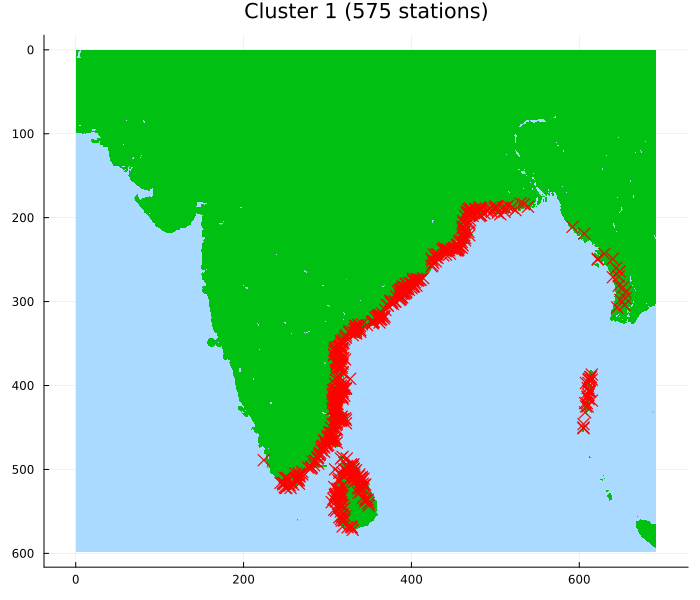

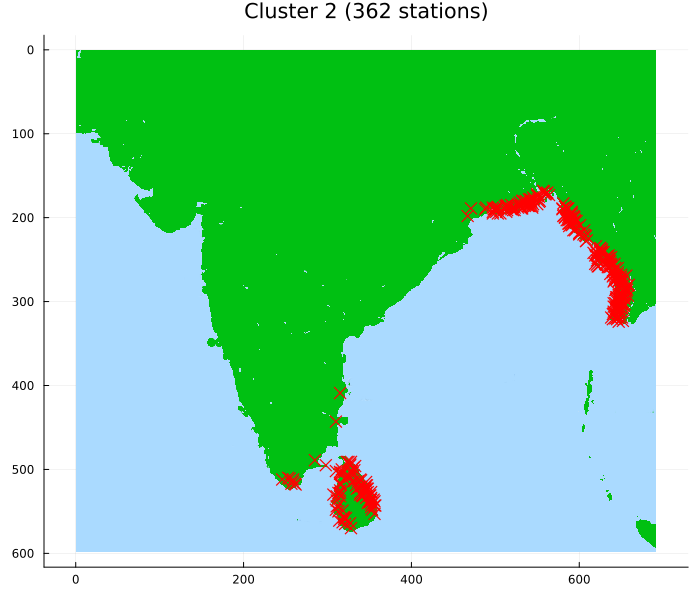

In [259]:
labels2 = spectral_clustering(W_knn, 2)

for cl in 1:2
    idx = findall(labels2 .== cl)
    n_stations = length(idx)

    p = plot(map_img,
             aspect_ratio = :equal,
             title = "Cluster $cl ($n_stations stations)",
             size = (700, 600))

    scatter!(p, y_coords[idx], x_coords[idx],
             color = :red,
             markershape = :x,
             markersize = 6,
             label = "")

    display(p)
end

Does the general conclusion
change?

With spectral clustering to two clusters, we can still notice how pollution of the Indian coast (and islands) is mostly similar to itself, whereas polution in Bangladesh and Myanmar is distinct and forms another major cluster. Sri Lanka is seperated between the two, with the coast facing India more similar to Indian-type pollution, and the coeast facing outwards more similar to the oter side of the bay. Compared to the seven clusters, this is a less specific categorziation, but still makes sense and the general conclusion of how to organize the cleaning efforts by stations might not differ that much.

### Part (f)

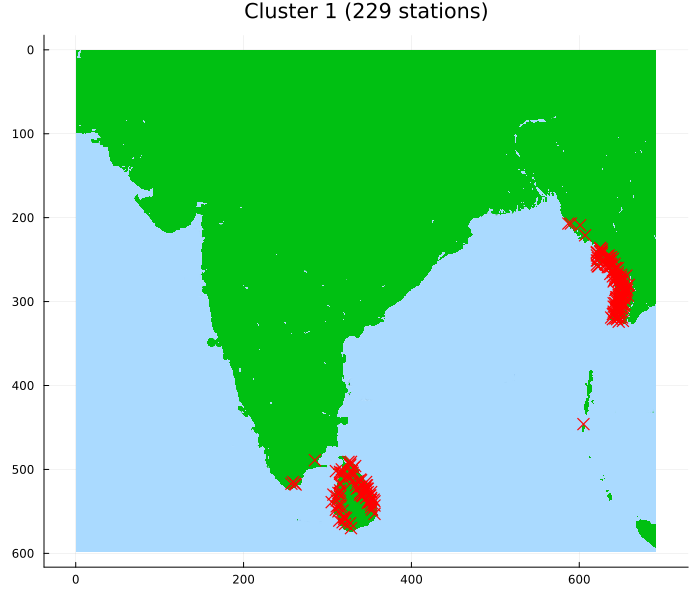

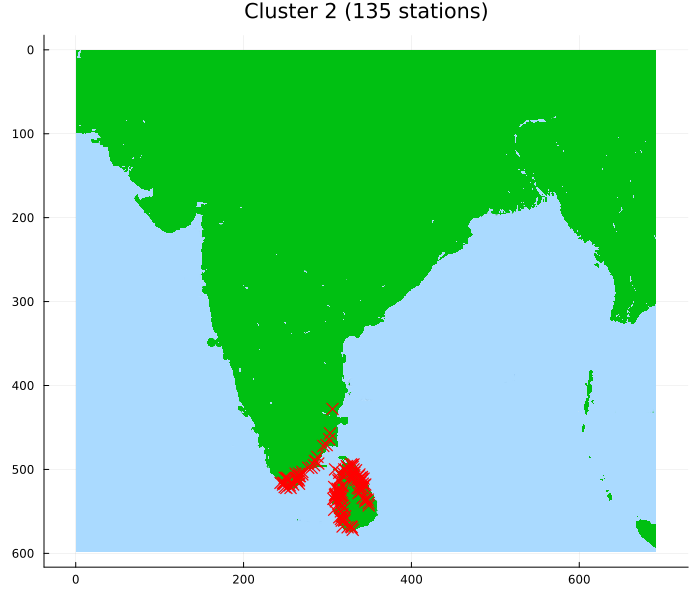

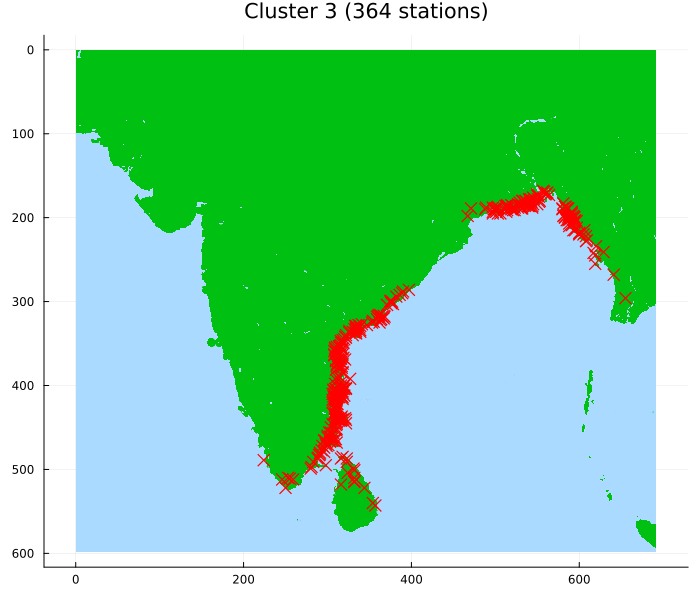

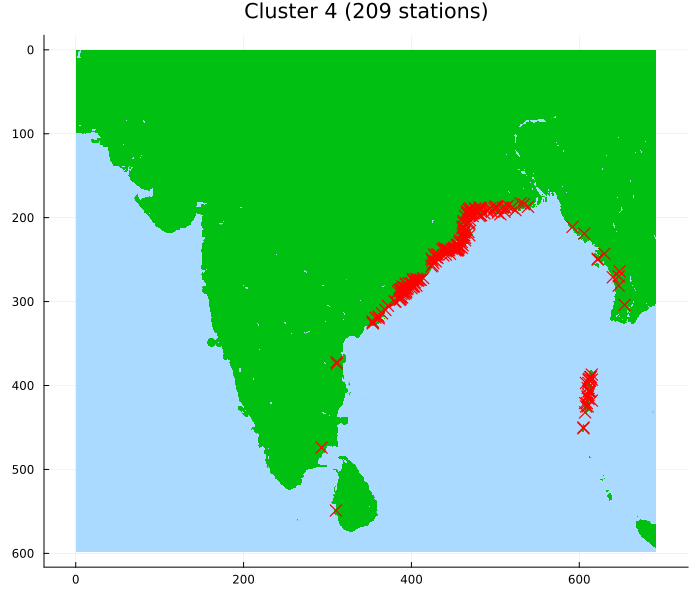

In [260]:
labels = 4
labels_test = spectral_clustering(W_knn, labels)

for cl in 1:labels
    idx = findall(labels_test .== cl)
    n_stations = length(idx)

    p = plot(map_img,
             aspect_ratio = :equal,
             title = "Cluster $cl ($n_stations stations)",
             size = (700, 600))

    scatter!(p, y_coords[idx], x_coords[idx],
             color = :red,
             markershape = :x,
             markersize = 6,
             label = "")

    display(p)
end

Sri-lanka seems to aggregate pollution from of both major types - Indian and the rest of the bay, while being the most similar to the southernmost part of India.

## Exercise 4

In [261]:
data_z = matread("zalando_clustering.mat")
items = data_z["items"] # 784 × 1000
correct = Int.(data_z["correct"])
# zalando_plot from HW1
function zalando_plot(z)
    A = reshape(z, 28, 28)
    A = A ./ maximum(abs.(A))
    B = 1 .- A'
    heatmap(B, color=:grays, aspect_ratio=1, axis=false)
end

zalando_plot (generic function with 1 method)

### Part (a)

In [262]:
# Two types: T-shirt (1) and Trouser (2)
println("Item types: ", unique(correct))

Item types: [2, 1]


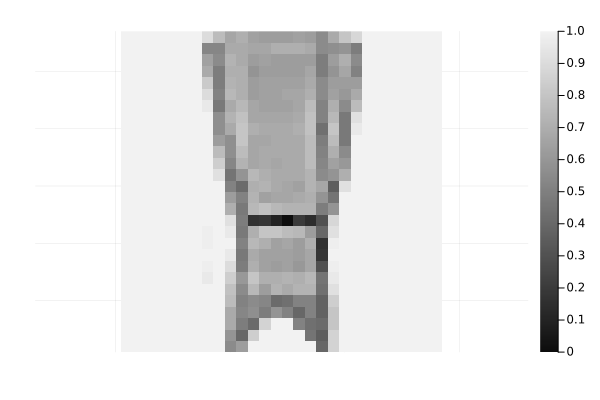

In [263]:
item_type1 = zalando_plot(items[:,1])

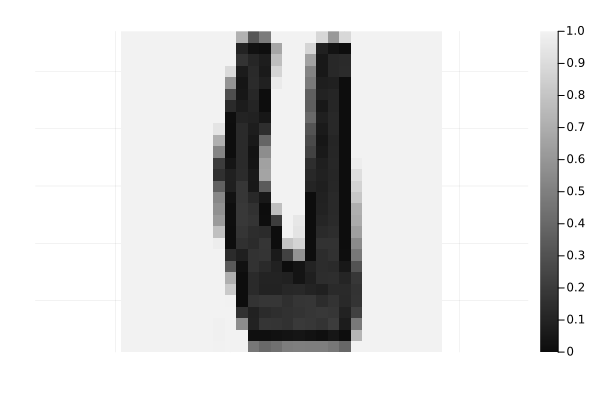

In [264]:
item_type2 = zalando_plot(items[:,2])

Items contain dresses and pants.

### Part (b)

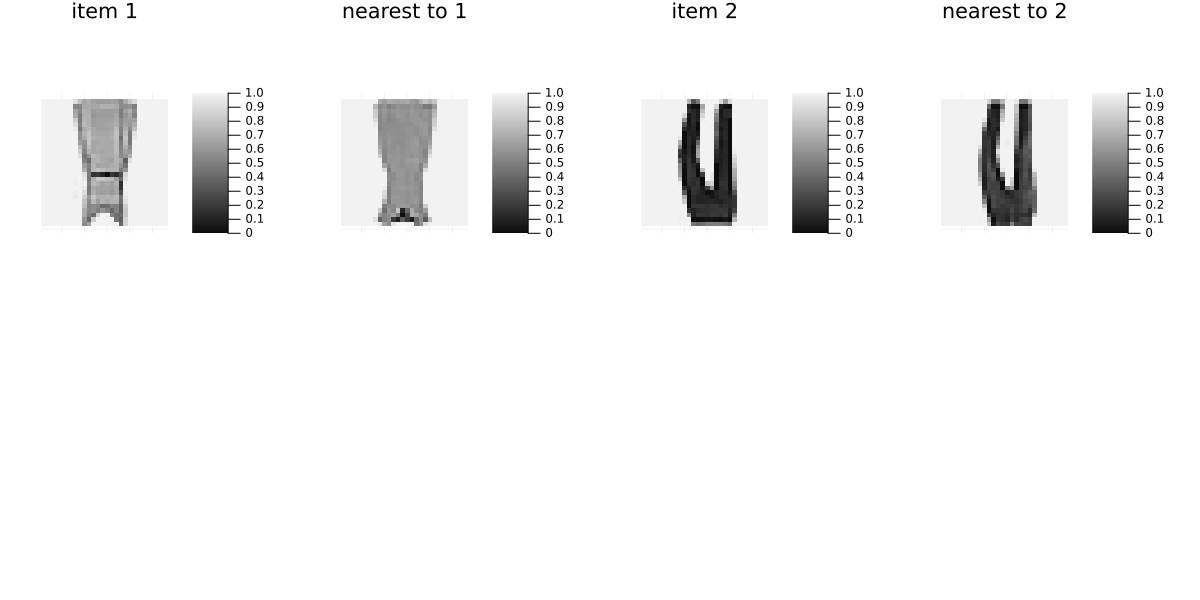

In [265]:
w = ones(784) # unweighted first
D = zeros(1000,1000)
for i in 1:1000
    for j in i+1:1000
        D[i,j] = norm(w .* (items[:,i] - items[:,j]))
        D[j,i] = D[i,j]
    end
end

# Create individual plots
plot1 = zalando_plot(items[:,1])
plot!(plot1, title="item 1")

nearest_to_1_idx = argmin(D[1,2:end]) + 1
plot2 = zalando_plot(items[:, nearest_to_1_idx ])
plot!(plot2, title="nearest to 1")

plot3 = zalando_plot(items[:,2])
plot!(plot3, title="item 2")

temp_distances_item2 = D[2,:]
temp_distances_item2[2] = Inf
nearest_to_2_idx = argmin(temp_distances_item2)
plot4 = zalando_plot(items[:, nearest_to_2_idx ])
plot!(plot4, title="nearest to 2")

# Combine plots into a single layout
p = plot(plot1, plot2, plot3, plot4, layout=(2,4), size=(1200,600))
display(p)

### Weight matrix

In [266]:
α = 0.5
W = zeros(1000,1000)
for i in 1:1000
    σ = std(D[i,:])
    for j in 1:1000
        W[i,j] = exp(-α * D[i,j]^2 / σ^2)
    end
end
W[diagind(W)] .= 0
W = (W + W') / 2

1000×1000 Matrix{Float64}:
 0.0          2.7222e-7    1.39076e-7   …  3.29781e-7   1.7907e-7
 2.7222e-7    0.0          0.00596942      2.16123e-5   0.256786
 1.39076e-7   0.00596942   0.0             0.000236629  0.0039663
 6.21456e-6   0.00185684   0.000352701     2.4358e-12   0.00134205
 2.16612e-6   0.00507045   0.0378311       0.000121141  0.00201516
 8.53465e-7   0.00035845   0.000194878  …  1.20266e-13  0.000498502
 2.30616e-6   0.00391418   0.0586753       2.88143e-5   0.00217525
 2.78039e-5   7.29262e-6   4.42594e-5      8.46673e-9   3.57547e-6
 2.21873e-7   0.0046296    0.0195518       1.25622e-6   0.00515422
 0.00114275   1.56735e-5   3.87226e-6      5.95449e-11  1.52922e-5
 0.0361978    5.10391e-7   3.71066e-7   …  2.40908e-6   2.94011e-7
 0.000474268  1.19462e-6   1.39895e-6      1.52236e-6   7.67942e-7
 7.9656e-6    6.01724e-5   0.000163588     1.02006e-6   4.75365e-5
 ⋮                                      ⋱               
 0.000217565  0.00156636   0.00228841      3.723

### Part (c)

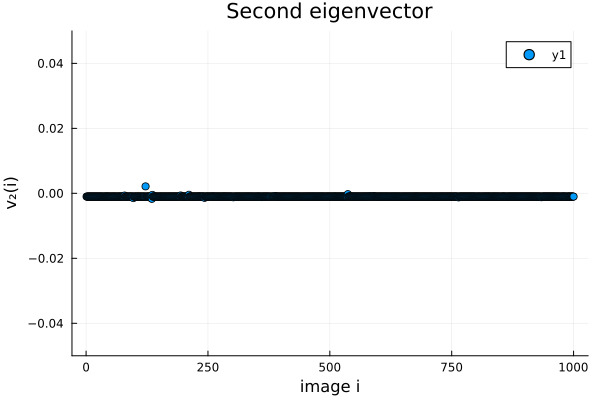

In [267]:
# Laplacian + second eigenvector
Deg = Diagonal(vec(sum(W,dims=2)))
L = Deg - W
F = eigen(L)
idx = sortperm(F.values)
v2 = F.vectors[:, idx[2]]

# Plot v2
plot(v2 ./ norm(v2), seriestype=:scatter, xlabel="image i", ylabel="v₂(i)", title="Second eigenvector", ylim=(-0.05,0.05))

The plot suggests the spectral clustering does not work well in our case. We expected two clusters, but are observing one. This means we do not have many items close to two discrete values, but rather one value.

### Part (d)

In [268]:
τ = median(v2)
classification = [v2[i] < τ ? 1 : 2 for i in 1:1000]
accuracy = mean(classification .== correct) * 100
println("Correctly classified: ", round(accuracy, digits=1), "%")

Correctly classified: 81.8%


### Part (e)

Showing first 4 misclassified images → indices: [3, 13, 27, 28]


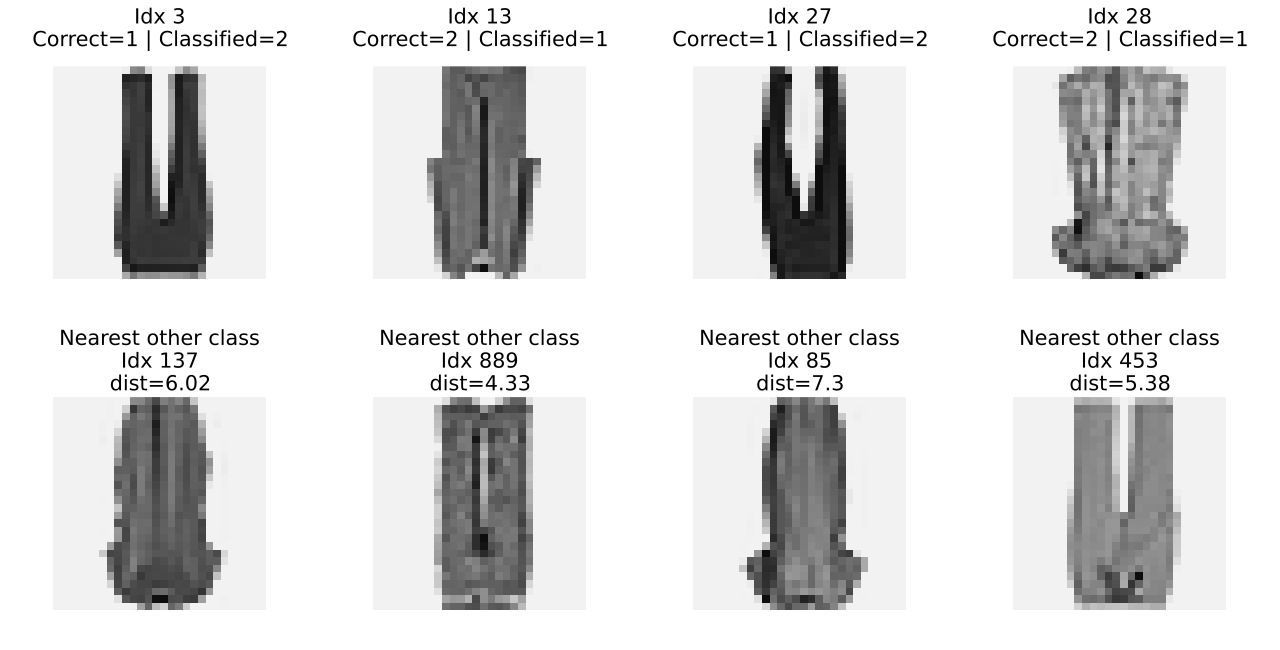

In [269]:
correct = vec(correct)
tau = median(v2)
predicted = [v2[k] < tau ? 1 : 2 for k in 1:length(v2)]
mis_idx = findall(predicted .!= correct)
misclassified = mis_idx[1:min(4, length(mis_idx))]

println("Showing first 4 misclassified images → indices: ", misclassified)

p = plot(layout = (2, length(misclassified)),
         size = (320*length(misclassified), 650),
         margin = 8Plots.mm)

for col in 1:length(misclassified)
    i = misclassified[col]

    # Misclassified image
    img = reshape(items[:, i], 28, 28)
    A = img ./ maximum(abs.(img))
    B = 1 .- A'
    heatmap!(p[col], B,
             color = :grays,
             aspect_ratio = 1,
             axis = false,
             ticks = false,
             colorbar = false,
             title = "Idx $i\nCorrect=$(correct[i]) | Classified=$(predicted[i])")

    # Nearest image from the other class
    other_class = 3 - correct[i]
    candidates = findall(correct .== other_class)
    dists = [D[i, j] for j in candidates]
    best_k = candidates[argmin(dists)]

    img2 = reshape(items[:, best_k], 28, 28)
    A2 = img2 ./ maximum(abs.(img2))
    B2 = 1 .- A2'
    heatmap!(p[col + length(misclassified)], B2,
             color = :grays,
             aspect_ratio = 1,
             axis = false,
             ticks = false,
             colorbar = false,
             title = "Nearest other class\nIdx $best_k\ndist=$(round(D[i, best_k], digits=2))")
end

display(p)

### Part (f)

In [270]:
x = 2.0
W_weight = ones(28,28)
W_weight[12:16, :] .= x
w_weight = vec(W_weight)
w_weight ./= norm(w_weight)

# Recompute D with weight
D_weighted = zeros(1000,1000)
for i in 1:1000, j in i+1:1000
    D_weighted[i,j] = norm(w_weight .* (items[:,i] - items[:,j]))
    D_weighted[j,i] = D_weighted[i,j]
end

# Recompute W using D_weighted
α = 0.5
W_new = zeros(1000,1000)
for i in 1:1000
    σ = std(D_weighted[i,:])
    for j in 1:1000
        W_new[i,j] = exp(-α * D_weighted[i,j]^2 / σ^2)
    end
end
W_new[diagind(W_new)] .= 0
W_new = (W_new + W_new') / 2

# Laplacian + second eigenvector using W_new
Deg_new = Diagonal(vec(sum(W_new,dims=2)))
L_new = Deg_new - W_new
F_new = eigen(L_new)
idx_new = sortperm(F_new.values)
v2_new = F_new.vectors[:, idx_new[2]]

# Threshold at median for new classification
τ_new = median(v2_new)
classification_new = [v2_new[i] < τ_new ? 1 : 2 for i in 1:1000]
accuracy_new = mean(classification_new .== correct) * 100
println("Correctly classified with weighted norm: ", round(accuracy_new, digits=1), "%")

Correctly classified with weighted norm: 99.4%


## Exercise 5

### Video quiz 6: Eigenvalue multiplicity

Eigenvalue multiplicity comes in two flavors: algebraic and geometric.  Algebraic multiplicity counts how many times an eigenvalue appears as a root of the characteristic polynomial, while geometric multiplicity counts the number of linearly independent eigenvectors associated with that eigenvalue. For symmetric matrices, these multiplicities align, and eigenvectors of distinct eigenvalues are orthogonal, simplifying the basis selection for their eigenspaces.

### Video quiz 7a: Mincut

Mincut is a simple graph clustering method. It splits the graph into k groups by removing as few (or as light) edges as possible. The cut value is the total weight of edges that connect different groups. The algorithm finds the partition that makes this value as small as possible. This gives clusters that are well separated, but it sometimes creates unbalanced groups because it only cares about the number of edges cut, not the size of the clusters.

### Video quiz 7b: Rayleigh-Ritz theorem

The Rayleigh-Ritz theorem tells us how to find eigenvalues and eigenvectors of a symmetric matrix. To get the k-th smallest eigenvalue, we minimize the Rayleigh quotient $r(x) = (x^TAx)/(x^Tx)$, but with the condition that x must be orthogonal to the first (k-1) eigenvectors. The vector x that achieves the minimum is exactly the k-th eigenvector. This gives a clean variational way to compute eigenvalues without solving the full characteristic equation.

### Video quiz 8: Eigenvalue derivatives

When we slightly change a symmetric matrix A(ε) = A₀ + εA₁, both its eigenvalues and eigenvectors also change smoothly. We keep the eigenvector normalized (||x(ε)|| = 1). Using a first-order perturbation expansion, the eigenvector becomes x(ε) = x₀ + εx'(0) + higher-order terms, and the eigenvalue becomes λ(ε) = λ₀ + ελ'(0) + higher-order terms. The derivative λ'(0) tells us exactly how fast the eigenvalue moves when we perturb the matrix.

### Video quiz 9: Proof of the Rayleigh-Ritz theorem

To prove the Rayleigh-Ritz theorem, we first rewrite the problem using the eigendecomposition of A. Instead of minimizing over all vectors, we work in the coordinate system where A is diagonal. The orthogonality condition then simply means that the first (k-1) coordinates of our vector are zero. After this change of variables, the minimum of the Rayleigh quotient is obviously the k-th diagonal entry — which is exactly the k-th eigenvalue. This trick turns the original minimization into a trivial problem.